In [1]:
import custom_cmap
import os
import sys
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from moria import reduce

from pathlib import Path
from astropy.visualization import PercentileInterval

from astropy.io import fits
from astropy.visualization import LogStretch, ImageNormalize
import plotly.express as px
import numpy as np
from astropy.visualization import ImageNormalize, AsinhStretch, SqrtStretch, LogStretch, PowerStretch

plt.rcParams.update({'font.size':25})
plt.rc('text', usetex=True)
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2


In [2]:
directory = os.getcwd()
#code_directory = os.path.abspath("..")
#sys.path.append(code_directory)

# Understanding the main directory. 

The data directory should be organized as follows. You can look at the sample data folder to understand the directory strucutre you need.

<li>00.DATA</li>
<li>01.XYM</li>
<li>02.CMD</li>
<li>03.LOC_TRANS</li>
<li>04.PSF_EXTRACT</li>
<li>05.COORD_TRANS(OPTIONAL)</li>
<li>06.FIT</li>
<li>07.CALIBRATION</li>

This notebook calibraes HST with Keck images. 

NOTE: chmod +x program.src is a useful command to use whenever permissions are denied for a script. 

In [3]:
directory = os.getcwd()
#code_directory = os.path.abspath("..")
#sys.path.append(code_directory)

# Step 0

The conditions that need to be met in order to run module 05 are:

1. Keck follow-up data has been taken on the specific target.
2. Both the KAI and DAOPHOT pipelines have previously been run on the Keck data to generate the *.fits stacked image and the *.als starlist.

# Step 1

Preparing the files needed for this module

In [8]:
reduce.data_prep_module_five(directory)

# Step 2

This is a manual step.

We need to identify a set of relatively isolated, bright (but not saturated) stars in both the Keck and HST images. While the Keck images are oriented with North = up and East = left, the HST images have much more random orientations. 

The coordinates of the HST and Keck stars matched by eye should then be written to the file IN.approx_matched_HST_Keck_stars, which lists the coordinates with the ordering: x_hst, y_hst, x_keck, y_keck, itarg, where itarg = 1 for the target star and = 0 for the other stars.



Use ds9 to open the fits file (F814W and the Keck fits file)

Here is an example of how the HST and Keck image were oriented to be such that North is up and East is to the left. The green circles indicate the chosen stars from Keck and HST images. 



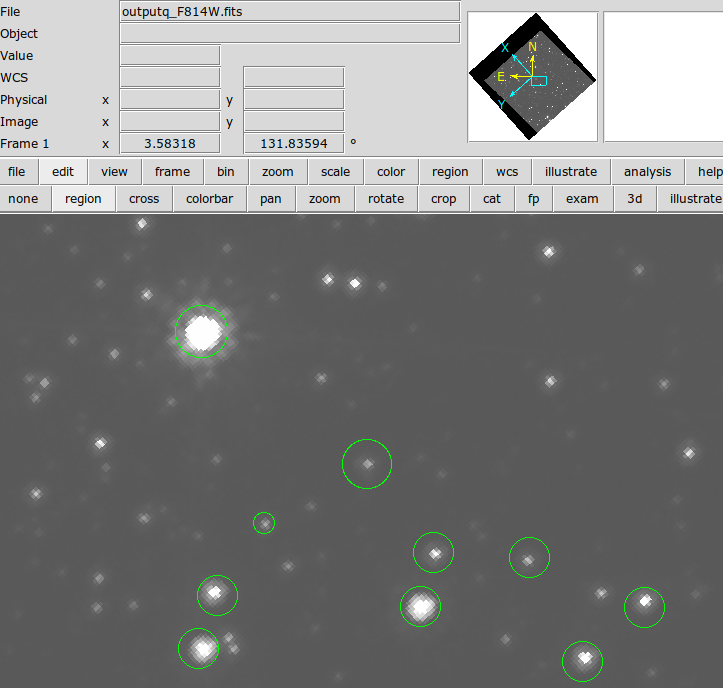

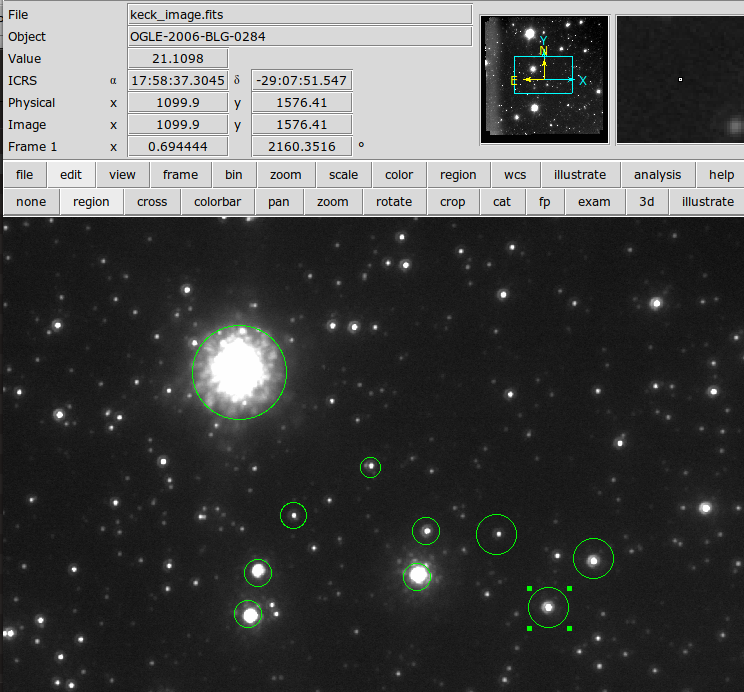



# Step 3

The coordinates of the HST and Keck stars matched by eye should then be written to the file IN.approx_matched_HST_Keck_stars, which lists the coordinates with the ordering: x_hst, y_hst, x_keck, y_keck, itarg, where itarg = 1 for the target star and = 0 for the other stars.


In [12]:
reduce.keck_trans(directory)